In [1]:
from utils import get_svamp_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_svamp_df("Direct Prompting")

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
Error processing ./ollama/smollm2_360m.xlsx: Worksheet named 'Error-Analysis' not found
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
smollm2_1.7b.xlsx


In [3]:
df.groupby("Model").agg({
    "is_correct": "sum",
})

,is_correct
Model,
google/gemma-3-27b-it,281
ollama/deepseek-r1_1.5b,237
ollama/gemma3_1b,197
ollama/llama3.2_1b,194
ollama/qwen2-math_1.5b,266
ollama/qwen2.5_0.5b,161
ollama/qwen3_0.6b,215
ollama/qwen3_1.7b,234
ollama/smollm2_1.7b,165


In [4]:
from chromadb import PersistentClient
import ollama

client = PersistentClient(path="chroma_db")
collection = client.get_or_create_collection(name="SVAMP_semantic_analysis")

entries = {}
for _, row in df.iterrows():
    if row["ID"] not in entries:
        entries[row["ID"]] = row["question"]

print(entries)

{'chal-736': 'Winter is almost here and most animals are migrating to warmer countries. There are 41 bird families living near the mountain. If 35 bird families flew away to asia and 62 bird families flew away to africa How many more bird families flew away to africa than those that flew away to asia?', 'chal-162': 'Paige raised 7 goldfish and 12 catfish in the pond but stray cats loved eating them. Now she has 15 left. How many fishes disappeared?', 'chal-390': 'Debby bought 200 water bottles and 256 soda bottles when they were on sale. If she drank 312 water bottles and 4 soda bottles a day How many days would the soda bottles last?', 'chal-781': "There were 106 dollars in Olivia's wallet. After she visited a supermarket and a showroom there were 26 dollars left. If she spent 49 dollars at the showroom How much did she spend at the supermarket?", 'chal-575': 'Faye was placing her pencils and crayons into 30 rows with 71 crayons and 24 pencils in each row. How many pencils does she ha

In [6]:
from tqdm import tqdm

for idx, question in tqdm(entries.items(), total=len(entries)):
    emb = ollama.embed(
        model="all-minilm:33m",
        input=question
    )
    embeddings = emb.embeddings[0]
    collection.upsert(
        documents=[question],
        embeddings=[embeddings],
        metadatas=None,
        ids=[str(idx)]
    )

  0%|          | 0/284 [00:00<?, ?it/s]

100%|██████████| 284/284 [00:06<00:00, 40.70it/s]


In [5]:
import numpy as np
all_items = collection.get(include=['embeddings'])
embeddings = np.array(all_items['embeddings'])

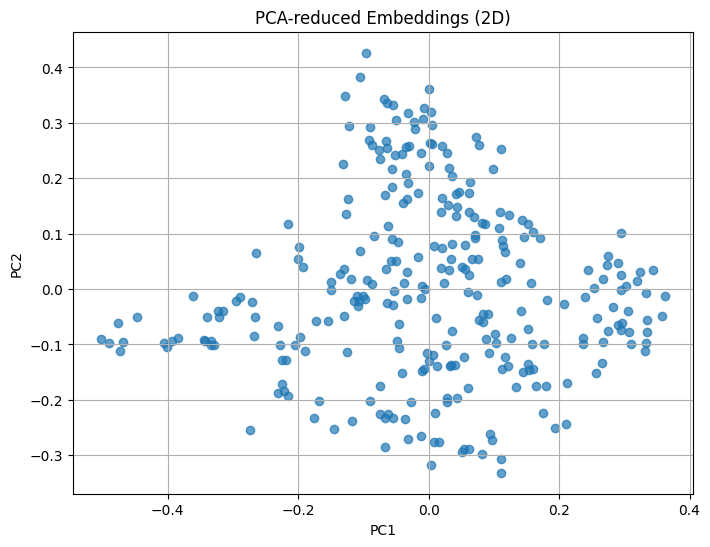

In [6]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import chromadb

# 3. Apply PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 4. (Optional) Visualize
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7)
plt.title("PCA-reduced Embeddings (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [7]:
from sklearn.cluster import KMeans

# 1. Apply K-Means clustering
num_clusters = 52  # You can adjust the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

In [8]:
# Print out some clusters and their corresponding items
entry_keys = list(entries.keys())  # Get the original keys from entries
def get_original_key(idx):
    return entry_keys[idx]  # Map numerical index to original key

In [9]:
cluster_data = {}
cluster_mapping= {}
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    cluster_data[cluster] = []
    cluster_indices = np.where(labels == cluster)[0]
    for idx in cluster_indices:  # Print up to 5 items per cluster
        original_key = get_original_key(idx)
        print(f"  Item {original_key}: {entries[original_key]}")
        cluster_data[cluster].append(original_key)
        cluster_mapping[original_key] = cluster
    print("\n")

Cluster 0:
  Item chal-856: Jesse's room is 7 feet long. If she needs a carpet of size 14 square feet What is the width of her room?
  Item chal-253: Jesse's rooms are 19 feet long and 18 feet wide. If she has 20 rooms in all How much carpet does she need to cover the floors of all rooms?


Cluster 1:
  Item chal-380: Rachel had to complete 5 pages of math homework and 2 pages of reading homework. How many more pages of math homework than reading homework did she have?
  Item chal-254: Rachel had to complete 10 pages of math homework. If she had to complete 3 more pages of reading homework than math homework How many pages did she have to complete in all?


Cluster 2:
  Item chal-599: Ed had 10 more marbles than Doug. Doug lost 11 of his marbles at the playground. If Ed had 45 marbles How many more marbles did Ed have than Doug then?
  Item chal-984: In Haley's class some boys love to play marbles. If Haley has 10 marbles and she gave 5 marbles to each boy How many boys did she give th

In [11]:
df['Cluster'] = df['ID'].map(cluster_mapping)
cluster_analysis = df.groupby(['Cluster', 'Model']).agg({'is_correct': 'sum'}).reset_index()
cluster_analysis.rename(columns={'is_correct': 'Correct_Count'}, inplace=True)
cluster_analysis["Cluster-len"] = cluster_analysis['Cluster'].map(lambda x: len(cluster_data[x]) if x in cluster_data else 0)
cluster_analysis["Wrong_Count"] = cluster_analysis["Cluster-len"] - cluster_analysis["Correct_Count"]
cluster_analysis["Correct_Score"] = cluster_analysis['Correct_Count'] / cluster_analysis["Cluster-len"] * 100
cluster_analysis["Wrong_Score"] = cluster_analysis['Wrong_Count'] / cluster_analysis["Cluster-len"] * 100
# Display the results
cluster_analysis.head()

,Cluster,Model,Correct_Count,Cluster-len,Wrong_Count,Correct_Score,Wrong_Score
0,0,google/gemma-3-27b-it,2,2,0,100.0,0.0
1,0,ollama/deepseek-r1_1.5b,2,2,0,100.0,0.0
2,0,ollama/gemma3_1b,2,2,0,100.0,0.0
3,0,ollama/llama3.2_1b,2,2,0,100.0,0.0
4,0,ollama/qwen2-math_1.5b,2,2,0,100.0,0.0


In [12]:
# Pivot the cluster_analysis DataFrame to get clusters as rows and models as columns
cluster_pivot = cluster_analysis.pivot(index='Cluster', columns='Model', values='Wrong_Count')
# Display the new DataFrame
cluster_pivot.head(55)

Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_1.7b
Cluster,,,,,,,,,
0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1
2,1,1,2,6,0,5,1,4,5
3,0,0,1,1,1,2,1,1,0
4,0,1,2,1,0,3,1,2,1
5,0,0,3,2,0,1,0,0,3
6,0,0,2,1,0,2,2,0,4
7,0,3,4,3,1,4,5,3,5
8,0,3,1,3,0,3,5,5,2


In [14]:
# Pivot the cluster_analysis DataFrame to get clusters as rows and models as columns
cluster_pivot = cluster_analysis.pivot(index='Cluster', columns='Model', values='Wrong_Score')
# Display the new DataFrame
cluster_pivot.head(55)

Model,google/gemma-3-27b-it,ollama/gemma3_1b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b
Cluster,,,,
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,9.090909,18.181818,45.454545,9.090909
3,0.0,20.0,40.0,20.0
4,0.0,18.181818,27.272727,9.090909
5,0.0,75.0,25.0,0.0
6,0.0,28.571429,28.571429,28.571429
7,0.0,40.0,40.0,50.0
8,0.0,16.666667,50.0,83.333333
